# Siamese

## 0. Imports

In [1]:
import os
import sys

# Get the absolute path of the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)


In [2]:
import itertools
from dataclasses import dataclass

import pandas as pd
from pathlib import Path
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

import evaluation as evals
import plotter as plotter


## 1. Load Data

In [ ]:
data_dir = Path("../../data/")

# read features
features_path = data_dir / "features_df.csv"
features_df = pd.read_csv(f"{features_path}")
print(f"Features Shape: {features_df.shape}")


In [ ]:
# optionally read the edgelist in for now
edgelist_path = data_dir / "edgelists" / "edgelist_full.csv"
edgelist = pd.read_csv(f"{edgelist_path}")
print(f"Edgelist Shape: {edgelist.shape}")


## 2. Pre-processing

In [ ]:
# save user ids for mapping
user_ids = features_df["user_id"].values

# one-hot encode all categorical
cat_cols = features_df.select_dtypes(include=["object", "bool"]).columns.tolist()
if "user_id" in cat_cols:
    cat_cols.remove("user_id")
df_numeric = features_df.drop(columns=["user_id"])
df_numeric = pd.get_dummies(df_numeric, columns=cat_cols)
print("One-hot encoding complete")

# fillna with median
df_numeric = df_numeric.fillna(df_numeric.median())
print("Filled missing with median")

# standardize and construct the X matrix
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)
print(X.shape)

X_train, X_test, ids_train, ids_test = train_test_split(
    X, user_ids, test_size=0.2, random_state=42
)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")


Cleaning feature matrix...
Retained 119 numeric features.


## 3. Training Siamese

Here's where the fun stuff starts

### Why is it complex?

The structure of our data for training is kind of like this matrix:

$$
\begin{bmatrix}
 \text{Features(Anchor User)} \\
 \text{Features(Positive Match)} \\
 \text{Features(Negative Match)} \\
\end{bmatrix}
$$

We have a set of all these matrices, across all our users. This isn't a typical csv file 
that we can just pass in as an input. So, we need to define a custom `Dataset` class – 
TripletDataset. This tells torch how to read our data during training. We connect 
TripletDataset dataset class to the edge list (containing labels) and the features_df 
containing all the features. 

In [3]:
import random
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn


class TripletDataset(Dataset):
    def __init__(self, edge_list, features_df):
        self.edge_list = edge_list.reset_index(drop=True)
        self.features_df = features_df

        # keep a list of all users for easy sampling
        self.all_users = list(features_df.index)

    def __len__(self):
        return len(self.edge_list)

    def __getitem__(self, idx):
        # 1. Look up the positive pair from the edge list
        row = self.edge_list.iloc[idx]
        anchor_id = row["user_id_anchor"]
        positive_id = row["user_id_positive"]

        # 2. Sample a random Negative user
        negative_id = random.choice(self.all_users)
        while negative_id == anchor_id or negative_id == positive_id:
            negative_id = random.choice(
                self.all_users
            )  # Keep trying until we get a non-match

        # 3. Fetch their feature vectors and convert to PyTorch Tensors
        # (We use float32 because neural network weights default to float32)
        feat_a = torch.tensor(
            self.features_df.loc[anchor_id].values, dtype=torch.float32
        )
        feat_p = torch.tensor(
            self.features_df.loc[positive_id].values, dtype=torch.float32
        )
        feat_n = torch.tensor(
            self.features_df.loc[negative_id].values, dtype=torch.float32
        )

        return feat_a, feat_p, feat_n

### Model

Simple neural network. Used basic architecture settings from Philip's class

In [7]:
class UserEmbeddingMLP(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super(UserEmbeddingMLP, self).__init__()

        # standard funnel shaped network
        # TODO: hyperparameter stuff
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim),
        )

    def forward(self, x):
        return self.network(x)

### Training Loop

configs are right on top

In [8]:
# Hyperparameters
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 0.001
INPUT_DIM = scaled_features_df.shape[1]

print(f"Initializing training with {INPUT_DIM} input features...")

dataset = TripletDataset(edge_list, scaled_features_df)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# model optimizer settings
model = UserEmbeddingMLP(input_dim=INPUT_DIM, embedding_dim=32)
criterion = nn.TripletMarginLoss(margin=1.0, p=2)  # p=2 means Euclidean distance
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. Train!
model.train()
loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for batch_a, batch_p, batch_n in dataloader:
        # zero out the gradients from the last step
        optimizer.zero_grad()

        # Pass all three batches through the exact same twin network
        emb_a = model(batch_a)
        emb_p = model(batch_p)
        emb_n = model(batch_n)

        # Calculate how badly the model did
        loss = criterion(emb_a, emb_p, emb_n)

        # Backpropagation: calculate the weight updates
        loss.backward()

        # Optimizer: apply the weight updates
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_epoch_loss)
    print(f"Epoch {epoch + 1}/{EPOCHS} | Triplet Loss: {avg_epoch_loss:.4f}")

print("✅ Training complete!")

Initializing training with 119 input features...
Epoch 1/10 | Triplet Loss: 0.6213
Epoch 2/10 | Triplet Loss: 0.4271
Epoch 3/10 | Triplet Loss: 0.3710
Epoch 4/10 | Triplet Loss: 0.3447
Epoch 5/10 | Triplet Loss: 0.3154
Epoch 6/10 | Triplet Loss: 0.3061
Epoch 7/10 | Triplet Loss: 0.2901
Epoch 8/10 | Triplet Loss: 0.2778
Epoch 9/10 | Triplet Loss: 0.2735
Epoch 10/10 | Triplet Loss: 0.2667
✅ Training complete!


## Testing

As a call out, my expectation is that this model isn't very good. The reasons are:

- Naive features: I just used a basic set of information
- Simple labels: Not a complicated matching score – just common tracks. If we improve
that, we'll likely see much higher quality matches


#### What do the cells do?

The first cell is basically checking two from the edge list (so two good pairs), and then
sampling a random negative pair. It's confirming that the pair is closer than the 
randomly selected user

The second cell is taking the ML output (32 dimensional vector), and doing PCA on it
to visualize in 2D. The expectation (hope) is that the anchor user is close to the 
positive match

In [9]:
model.eval()
print("Running Sanity Check...")

# 1. Grab a test pair from the edge list (let's use the first row)
test_row = edge_list.iloc[0]
a_id = test_row["user_id_anchor"]
p_id = test_row["user_id_positive"]

# 2. Pick a random negative user
n_id = random.choice(dataset.all_users)
while n_id in [a_id, p_id]:
    n_id = random.choice(dataset.all_users)

# 3. Get their raw scaled features
feat_a = torch.tensor(scaled_features_df.loc[a_id].values, dtype=torch.float32)
feat_p = torch.tensor(scaled_features_df.loc[p_id].values, dtype=torch.float32)
feat_n = torch.tensor(scaled_features_df.loc[n_id].values, dtype=torch.float32)

# 4. Generate their 32D Embeddings (No gradients needed for inference)
with torch.no_grad():
    emb_a = model(feat_a)
    emb_p = model(feat_p)
    emb_n = model(feat_n)

# 5. Calculate Euclidean Distances
dist_positive = torch.pairwise_distance(emb_a.unsqueeze(0), emb_p.unsqueeze(0)).item()
dist_negative = torch.pairwise_distance(emb_a.unsqueeze(0), emb_n.unsqueeze(0)).item()

print(f"Anchor User: {a_id}")
print(f"Distance to True Future Match (Positive): {dist_positive:.4f}")
print(f"Distance to Random User (Negative):       {dist_negative:.4f}")

if dist_positive < dist_negative:
    print("✅ SUCCESS: The model correctly pulled the future friends closer together!")
else:
    print(
        "❌ FAIL: The model thinks the random user is a better match. (Try training for more epochs!)"
    )

Running Sanity Check...
Anchor User: 00028a63-2ba8-44fb-96d1-becb542f4a64
Distance to True Future Match (Positive): 4.4907
Distance to Random User (Negative):       7.5948
✅ SUCCESS: The model correctly pulled the future friends closer together!


Generating map of 1,000 users...


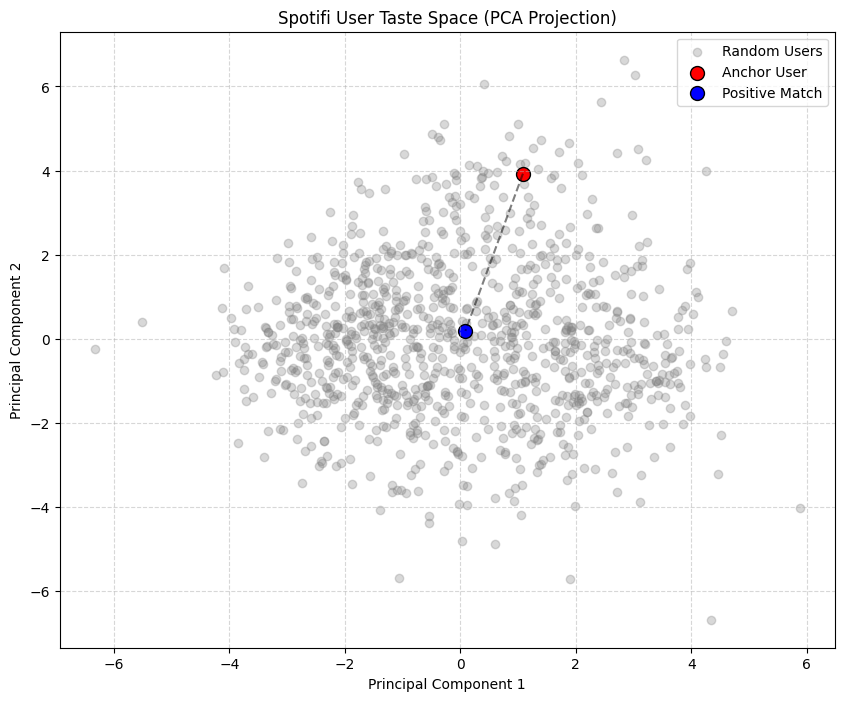

In [10]:
from sklearn.decomposition import PCA

print("Generating map of 1,000 users...")

# sample 1,000 random users to keep the plot clean
sample_users = scaled_features_df.sample(n=1000, random_state=42)

# ensure sample users are in the map
sample_users.loc[a_id] = scaled_features_df.loc[a_id]
sample_users.loc[p_id] = scaled_features_df.loc[p_id]

# create their embeddings
tensor_features = torch.tensor(sample_users.values, dtype=torch.float32)
with torch.no_grad():
    all_embeddings = model(tensor_features).numpy()

# do some PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# plot
plt.figure(figsize=(10, 8))

# plot the background users in light gray
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.3, c="gray", label="Random Users"
)

# Find the index of our Anchor and Positive to highlight them
idx_a = sample_users.index.get_loc(a_id)
idx_p = sample_users.index.get_loc(p_id)

# Plot the Anchor and Positive in bright red/blue
plt.scatter(
    embeddings_2d[idx_a, 0],
    embeddings_2d[idx_a, 1],
    c="red",
    s=100,
    edgecolors="black",
    label="Anchor User",
)
plt.scatter(
    embeddings_2d[idx_p, 0],
    embeddings_2d[idx_p, 1],
    c="blue",
    s=100,
    edgecolors="black",
    label="Positive Match",
)

# Draw a line connecting them
plt.plot(
    [embeddings_2d[idx_a, 0], embeddings_2d[idx_p, 0]],
    [embeddings_2d[idx_a, 1], embeddings_2d[idx_p, 1]],
    "k--",
    alpha=0.5,
)

plt.title("Spotifi User Taste Space (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()